## SARIMAX

**Objetivo:** desenvolver um modelo de previsão de PM2.5 utilizando SARIMAX, incorporando variáveis meteorológicas e sazonalidades temporais para previsão das próximas 24 horas.

*******
**Exploração e entendimento dos dados**
- Avaliando ciclos sazonais e correlação entre variáveis
- VIF (variáveis atmosféricas)
- Estacionaridade

************

**Experimentos SARIMAX**

Foram realizados diversos experimentos com o modelo SARIMAX para previsão de PM2.5 com horizonte de 24 horas. Os testes avaliaram diferentes configurações de:

- Tamanho do conjunto de treinamento (50%, 70%, 90% e 100% dos dados);
- Estratégias de tratamento de dados faltantes (sem interpolação, interpolação para gaps menores que 12 horas e preenchimento completo por média);
- Inclusão de variáveis exógenas meteorológicas (temperatura, umidade relativa, precipitação e velocidade do vento);
- Diferentes combinações dos parâmetros order (p,d,q) e seasonal_order (P,D,Q,24).
- Inclusão de variáveis exógenas sazonais (sin/cos do mês e decomposições de Fourier)

************

**Melhor Experimento**

- SARIMAX:
    order = (3,1,1) 
    seasonal_order = (0,1,1,24)

- Conjunto de dados: 100% dos dados (2016-2019) 

- Variáveis exógenas:
Temperatura do ar,
Umidade relativa,
Precipitação e
Velocidade do vento

- Interpolação: Sem interpolação

- Conjunto de dados:

      - train: (16104, 7) 2016-03-01 00:00:00+00:00 2017-12-31 23:00:00+00:00
      - val  : (8760, 7) 2018-01-01 00:00:00+00:00 2018-12-31 23:00:00+00:00
      - test : (5499, 7) 2019-01-01 00:00:00+00:00 2019-08-18 02:00:00+00:00

- Resultados obtidos no conjunto de validação em média:

    - MAE: 7.63 µg/m³
    - RMSE: 9.30 µg/m³
    - R²: -0.48

- Resultados obtidos no conjunto de teste em média:

    - MAE: 7.55 µg/m³
    - RMSE: 0.75 µg/m³
    - R²: -0.41


In [1]:
# import sys

# !{sys.executable} -m pip install -r requirements.txt

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from dateutil.relativedelta import relativedelta

### 1. Carregamento dos dados

In [3]:
# abrindo base de dados para treinamento - testando inicialmente com a série original com gaps
data = pd.read_csv("dados_full_feature_2016_2019_nan.csv")
#data = pd.read_csv("../data/data_interpolacao_gaps_maiores_medias/dados_pm25_umi_temp_2016_2019_fill_mean.csv")
data.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


In [4]:
data["time"] = pd.to_datetime(data["time"])
data = data.set_index("time").sort_index()

data.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
time,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


### 2. Exploração da Série Temporal (Ciclos)

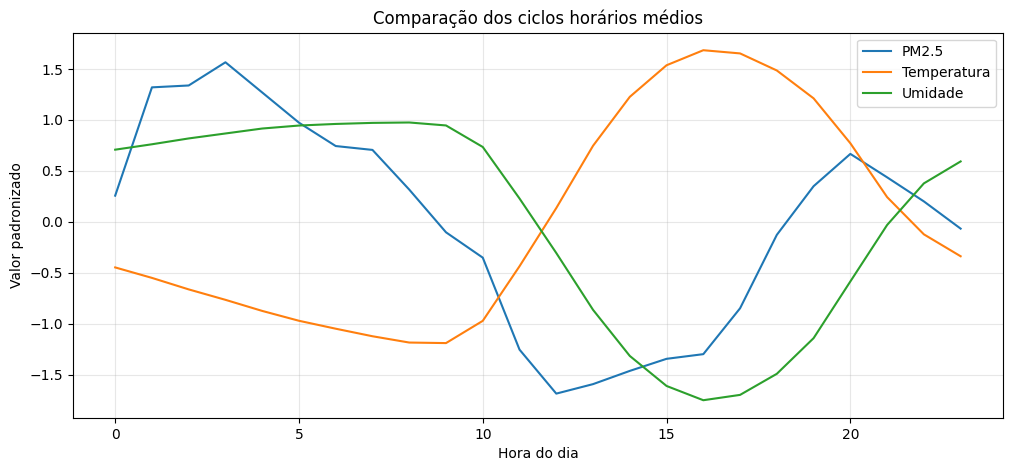

In [5]:
#ciclo diário
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.hour)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.hour)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.hour)["relative_humidity_2m"].mean()
})

ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos horários médios")
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.show()

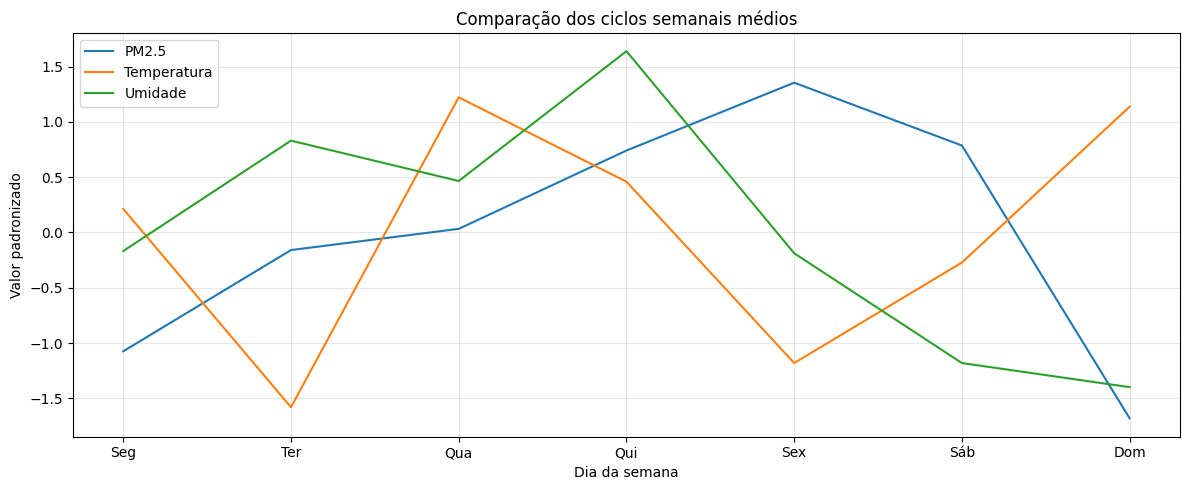

In [6]:
# ciclo semanal
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.dayofweek)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.dayofweek)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.dayofweek)["relative_humidity_2m"].mean()
})

ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
ciclo_norm.index = dias

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos semanais médios")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

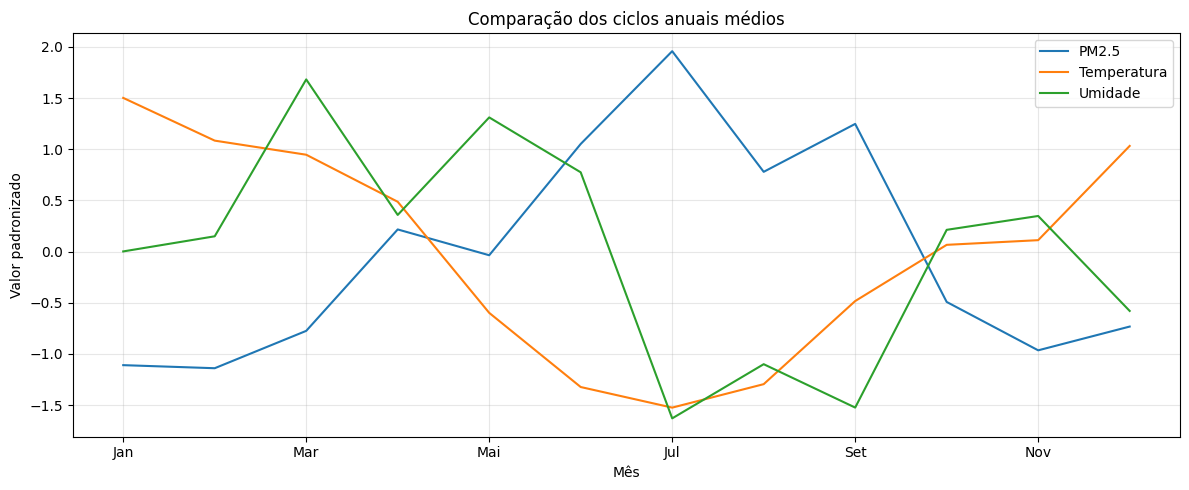

In [7]:
# ciclo anual
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.month)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.month)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.month)["relative_humidity_2m"].mean()
})


ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

meses = [
    "Jan", "Fev", "Mar", "Abr",
    "Mai", "Jun", "Jul", "Ago",
    "Set", "Out", "Nov", "Dez"
]

ciclo_norm.index = meses

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos anuais médios")
ax.set_xlabel("Mês")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Correlação entre variáveis

In [8]:
######### Temperatura e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_temp = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["temperature_2m"].shift(lag)
    )

    corr_temp.append(c)

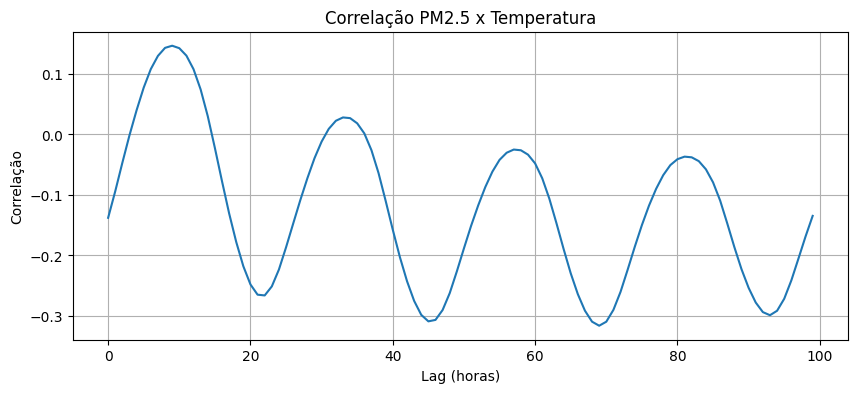

In [9]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_temp)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x Temperatura")
plt.grid()

plt.show()

In [10]:
######### umidade e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_umi = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["relative_humidity_2m"].shift(lag)
    )

    corr_umi.append(c)

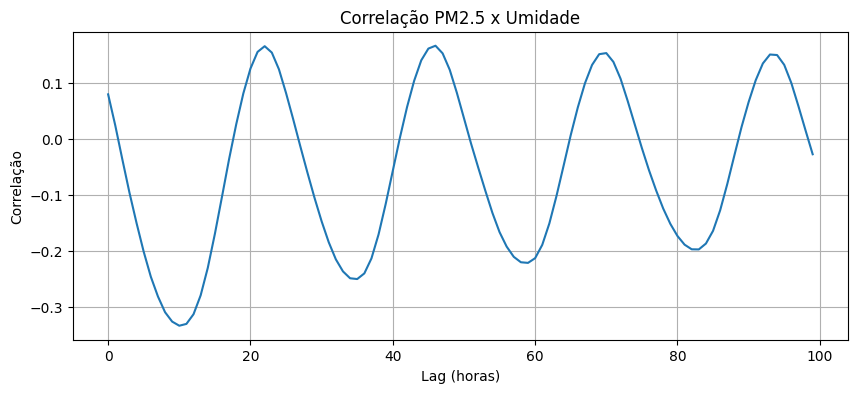

In [11]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_umi)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x Umidade")
plt.grid()

plt.show()

In [12]:
corr_pm25 = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["MP2.5"].shift(lag)
    )

    corr_pm25.append(c)

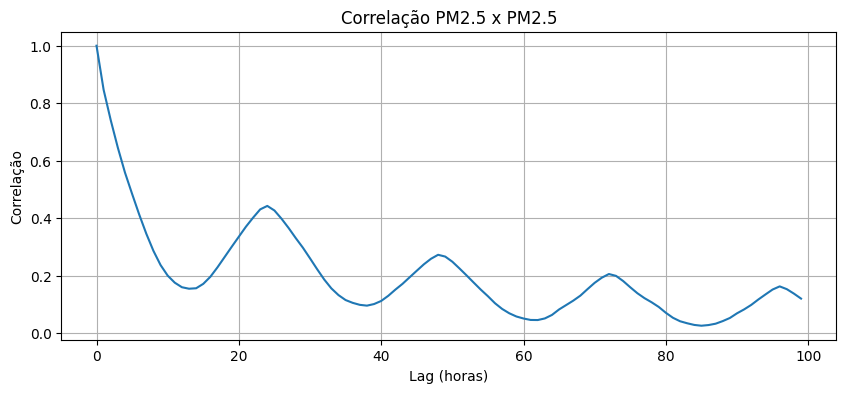

In [13]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_pm25)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x PM2.5")
plt.grid()

plt.show()

In [14]:
######### umidade e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_umi_temp = []

for lag in range(0, 100):

    c = data["temperature_2m"].corr(
        data["relative_humidity_2m"].shift(lag)
    )

    corr_umi_temp.append(c)

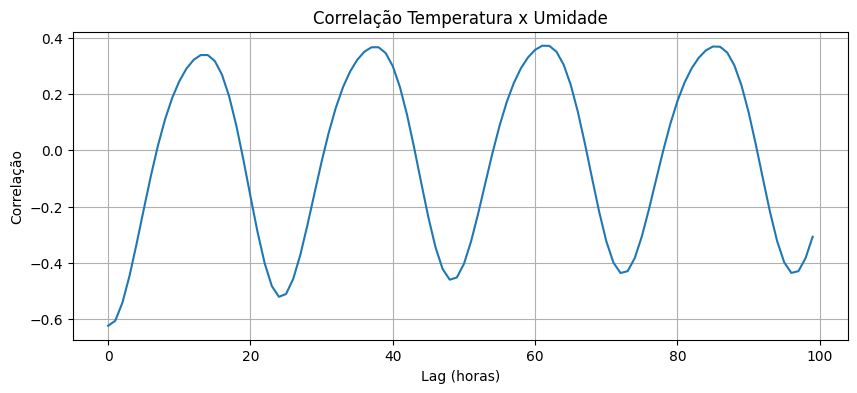

In [15]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_umi_temp)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação Temperatura x Umidade")
plt.grid()

plt.show()

### 4. VIF (Variance Inflation Factor): Investigando multicolinearidade entre as features

In [16]:
# normalizando utilizando StandardScaler()
cols = [
    "temperature_2m",
    "relative_humidity_2m"
]

scaler = StandardScaler()

data_scaled = data.drop(columns=["MP2.5"]).copy()
#data_scaled = data.copy()

data_scaled[cols] = scaler.fit_transform(
    data_scaled[cols]
)

data_scaled.head()

,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
time,,,,
2016-03-01 00:00:00+00:00,-0.303972,0.807668,1.0,12.538134
2016-03-01 01:00:00+00:00,-0.292856,0.867885,0.4,14.529915
2016-03-01 02:00:00+00:00,-0.281741,0.827881,0.3,12.538134
2016-03-01 03:00:00+00:00,-0.303972,0.887937,0.6,11.525623
2016-03-01 04:00:00+00:00,-0.292856,0.867885,0.5,12.979984


In [17]:
#Considerar VIF ≥  10 como um potencial problema

df = pd.DataFrame()

df["features"] = data_scaled.columns

df["vif_index"] = [vif(data_scaled.values, i) for i in range(data_scaled.shape[1])]

round(df.sort_values(by="vif_index", ascending = False),2)

,features,vif_index
1,relative_humidity_2m,1.68
0,temperature_2m,1.67
2,precipitation,1.07
3,wind_speed_10m,1.06


### 5. Entendendo estacionaridade e defasegem de PM2.5

In [18]:
# Avaliando período máximo contínuo sem gaps temporais para análise.
# Tentei fazer a análise com a série completa mas como tem gaps quis comparar também com uma série contínua
# para ter certeza que os gaps não estavam influenciando as estimativas, principalmente da estacionaridade.

def encontrar_segmentos_continuos(df, col="MP2.5", freq="h"):
    serie = df[col].copy()

    serie = serie.sort_index().asfreq(freq)

    valido = serie.notna()

    grupo = (valido != valido.shift()).cumsum()

    segmentos = []

    for _, bloco in serie.groupby(grupo):
        if bloco.notna().all():
            segmentos.append({
                "inicio": bloco.index[0],
                "fim": bloco.index[-1],
                "n_horas": len(bloco),
                "n_dias": len(bloco) / 24
            })

    segmentos = pd.DataFrame(segmentos)

    if segmentos.empty:
        return segmentos

    return segmentos.sort_values("n_horas", ascending=False).reset_index(drop=True)

In [19]:
segmentos = encontrar_segmentos_continuos(data, col="MP2.5", freq="h")
segmentos.head(10)

,inicio,fim,n_horas,n_dias
0,2016-11-08 18:00:00+00:00,2017-03-31 05:00:00+00:00,3420,142.500000
1,2019-03-05 17:00:00+00:00,2019-05-30 11:00:00+00:00,2059,85.791667
2,2018-12-26 15:00:00+00:00,2019-03-05 14:00:00+00:00,1656,69.000000
3,2017-11-07 14:00:00+00:00,2018-01-14 19:00:00+00:00,1638,68.250000
4,2017-05-04 17:00:00+00:00,2017-07-10 12:00:00+00:00,1604,66.833333
5,2018-04-05 12:00:00+00:00,2018-06-04 22:00:00+00:00,1451,60.458333
6,2018-01-17 03:00:00+00:00,2018-03-14 22:00:00+00:00,1364,56.833333
7,2016-07-17 12:00:00+00:00,2016-08-31 10:00:00+00:00,1079,44.958333
8,2016-05-01 16:00:00+00:00,2016-06-10 02:00:00+00:00,947,39.458333
9,2018-06-19 03:00:00+00:00,2018-07-24 19:00:00+00:00,857,35.708333


In [20]:
maior = segmentos.iloc[0]

inicio = maior["inicio"]
fim = maior["fim"]

data_continua = data.loc[inicio:fim].copy()

print(inicio, fim)
print(f"{maior['n_dias']:.1f} dias contínuos")

2016-11-08 18:00:00+00:00 2017-03-31 05:00:00+00:00
142.5 dias contínuos


In [21]:
# Avaliando impactos diretos e indiretos de PM2.5
def plot_autocorrelation(y, d=0, D=0, m=0):
    y = pd.Series(y)
    if D > 0:
        for i in range(D):
            y = y.diff(m)
    if d > 0:
        for i in range(d):
            y = y.diff(1)
    fig = plt.figure(figsize=(20,10))
    ax1 = fig.add_subplot(2,1,1)
    ax2 = fig.add_subplot(2,2,3)
    ax3 = fig.add_subplot(2,2,4)
    ax1.plot(y)
    plot_acf(y, lags = 50, ax=ax2);
    plot_pacf(y, lags=50, method='ywm', ax=ax3, color='r');
    plt.show()

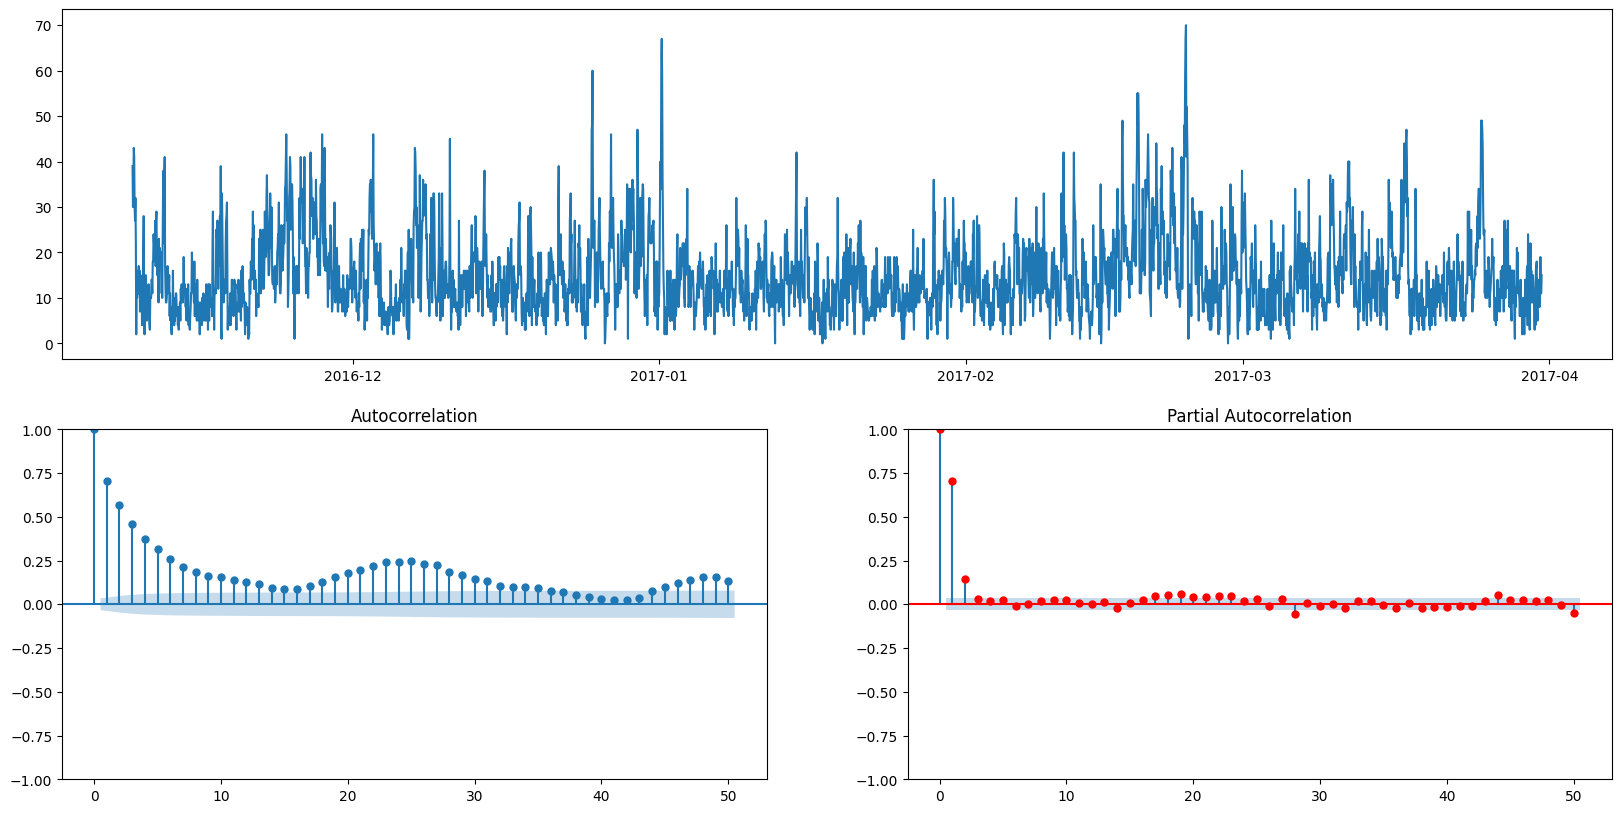

In [22]:
plot_autocorrelation(data_continua["MP2.5"], d=0, D=0, m=24)

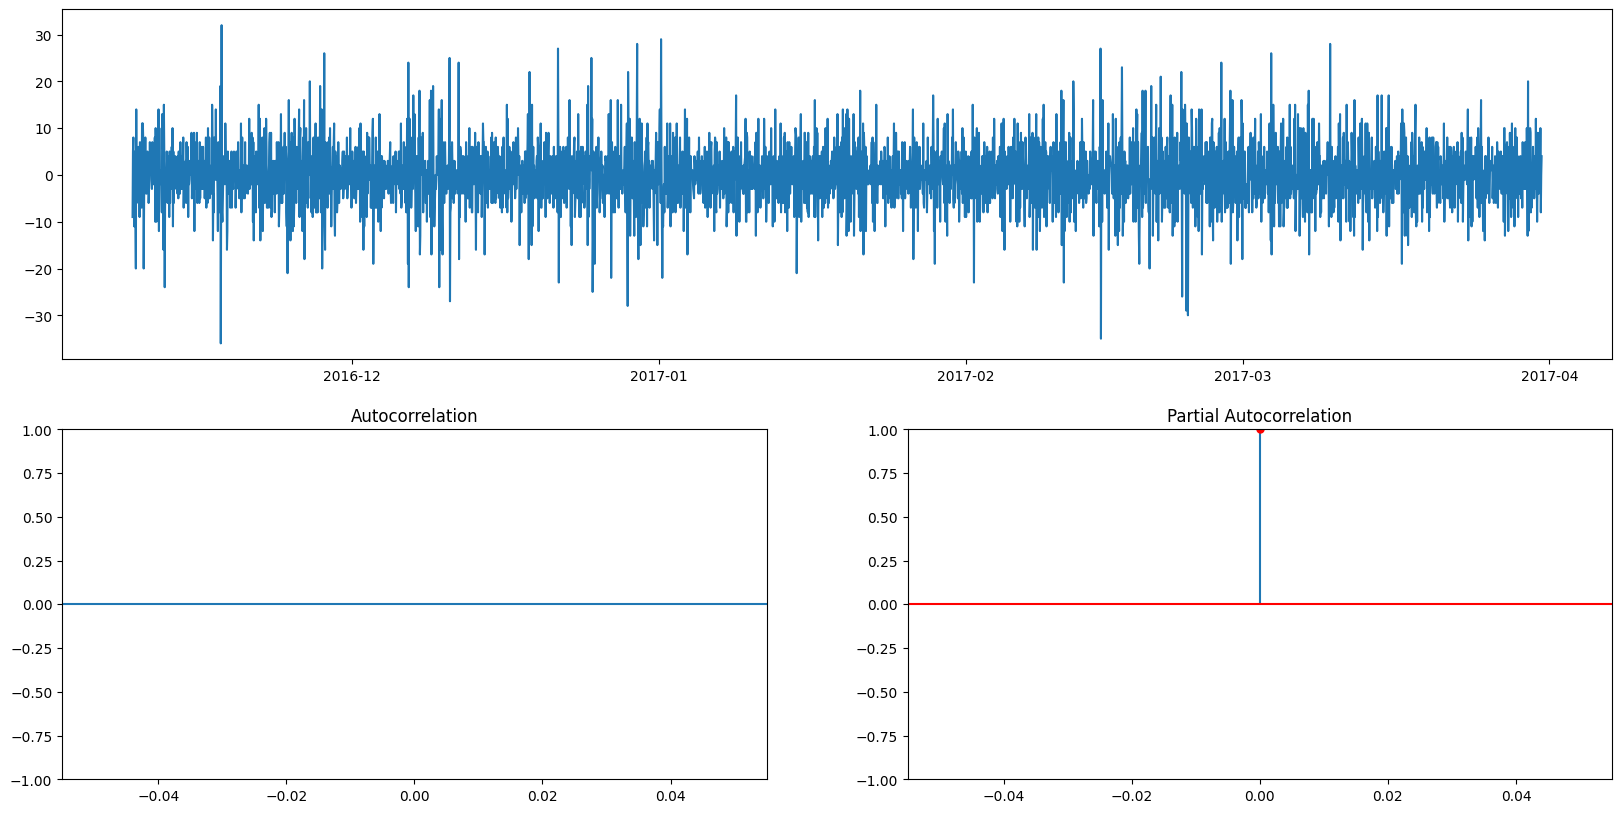

In [23]:
plot_autocorrelation(data_continua["MP2.5"],d=1,D=0,m=24)

Avaliando a Estacionaridade

**************
O p-valor deve ser menor que 0,05 para que possamos ter 95% de confiança de que a série é estacionária.

Idealmente, o p-valor deve ser muito menor que 0,05.
*************
seasonal_order=(P,1,Q,24)

In [24]:
result = adfuller(data_continua["MP2.5"])

print("ADF statistic:", result[0])
print("p-value:", result[1])

ADF statistic: -6.67762919168967
p-value: 4.423892863799103e-09


### 6. Selecionando dados utilizados e incluindo variáveis sazonais

In [25]:
# Se quiser avaliar diferentes % do conjunto de dados
metade = int(len(data) * 1)

data_50 = data.iloc[-metade:].copy()

In [26]:
# Adicionando a sazonalidade anual
month = data_50.index.month

data_50["month_sin"] = np.sin(2 * np.pi * month / 12)

data_50["month_cos"] = np.cos(2 * np.pi * month / 12)

In [27]:
data_50.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos
time,,,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134,1.0,6.123234e-17
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915,1.0,6.123234e-17
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134,1.0,6.123234e-17
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623,1.0,6.123234e-17
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984,1.0,6.123234e-17


### 6. Separando conjunto de treino, validação e teste

In [28]:
def split_temporal_sarimax(
    df,
    features,
    target,
    train_end="2018-01-01",
    val_end="2019-01-01"
):
    df = df.copy()
    df = df.sort_index()

    train = df.loc[df.index < train_end].copy()

    val = df.loc[
        (df.index >= train_end) &
        (df.index < val_end)
    ].copy()

    test = df.loc[df.index >= val_end].copy()

    exog_train = train[features]
    y_train = train[target]

    exog_val = val[features]
    y_val = val[target]

    exog_test = test[features]
    y_test = test[target]

    print("train:", train.shape, train.index.min(), train.index.max())
    print("val  :", val.shape, val.index.min(), val.index.max())
    print("test :", test.shape, test.index.min(), test.index.max())

    return exog_train, exog_val, exog_test, y_train, y_val, y_test

In [29]:
features_modelo = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m"]

target = "MP2.5"

exog_train, exog_val, exog_test, y_train, y_val, y_test = split_temporal_sarimax(
    data_50,
    features_modelo,
    target,
    train_end="2018-01-01",
    val_end="2019-01-01"
)


train: (16104, 7) 2016-03-01 00:00:00+00:00 2017-12-31 23:00:00+00:00
val  : (8760, 7) 2018-01-01 00:00:00+00:00 2018-12-31 23:00:00+00:00
test : (5499, 7) 2019-01-01 00:00:00+00:00 2019-08-18 02:00:00+00:00


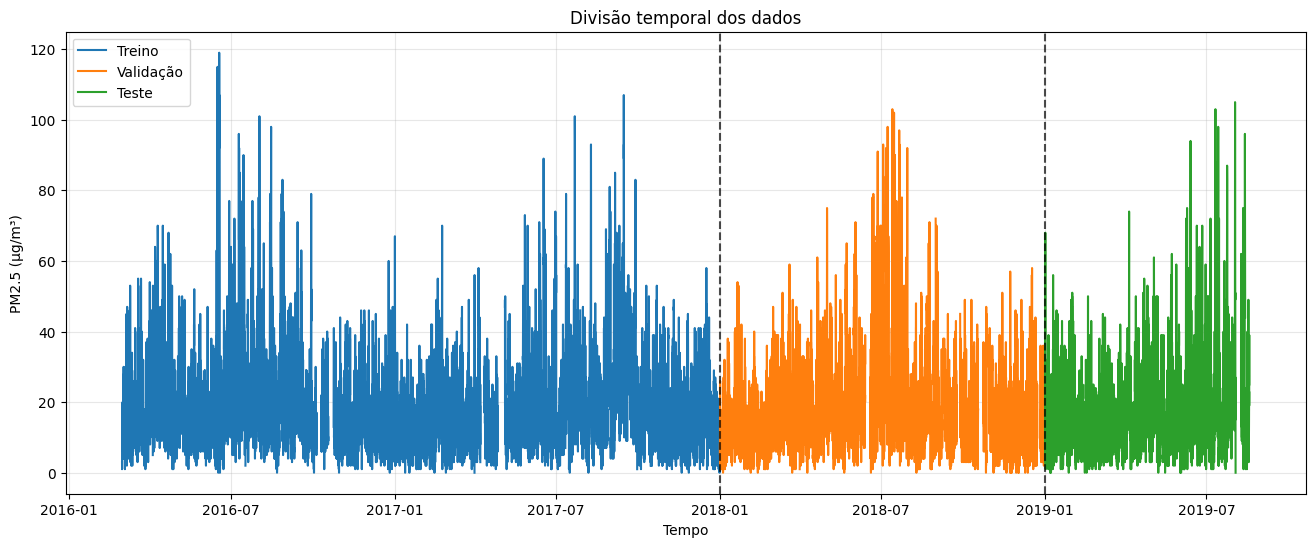

In [30]:
plt.figure(figsize=(16,6))

plt.plot(
    y_train,
    label="Treino",
    color="tab:blue"
)

plt.plot(
    y_val,
    label="Validação",
    color="tab:orange"
)

plt.plot(
    y_test,
    label="Teste",
    color="tab:green"
)

plt.axvline(
    y_val.index[0],
    color="black",
    linestyle="--",
    alpha=0.7
)

plt.axvline(
    y_test.index[0],
    color="black",
    linestyle="--",
    alpha=0.7
)

plt.title("Divisão temporal dos dados")
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Tempo")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 8. Baseline simples

In [31]:
# Seasonal Naive (24h) - VALIDAÇÃO
# observado nas primeiras 24h do teste
y_true = y_val.iloc[:24]

# Baseline = ultimas 24h do treino
y_baseline = y_train.iloc[-24:].copy()

y_baseline.index = y_true.index

mae_baseline = mean_absolute_error(y_true, y_baseline)
rmse_baseline = root_mean_squared_error(y_true, y_baseline)
r2_baseline = r2_score(y_true, y_baseline)

print(f"Baseline 24h - MAE : {mae_baseline:.3f}")
print(f"Baseline 24h - RMSE: {rmse_baseline:.3f}")
print(f"Baseline 24h - R²  : {r2_baseline:.3f}")

Baseline 24h - MAE : 5.375
Baseline 24h - RMSE: 7.536
Baseline 24h - R²  : -0.304


### 8. Modelagem

**8.1 Modelo único para testes**

In [32]:
# usando melhores parâmetros testados
order = (3,1,1)
seasonal_order = (0,1,1,24)

model = SARIMAX(
    y_train,
    exog=exog_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [33]:
# results = model.fit()

In [34]:
# print(results.summary())

In [35]:
# # previsão das próximas 24h
# forecast_24h = results.get_forecast(
#     steps=24,
#     exog=exog_val.iloc[:24]
# )

# forecast_mean = forecast_24h.predicted_mean
# conf_int = forecast_24h.conf_int()

# index_forecast = y_val.index[:24]

# forecast_mean.index = index_forecast
# conf_int.index = index_forecast

In [36]:
# # Figura
# plt.figure(figsize=(15, 6))

# # últimos dias observados
# plt.plot(
#     y_train.iloc[-24*7:],
#     label="Treino observado"
# )

# # comparar somente com +24h
# plt.plot(
#     y_val.iloc[:24],
#     label="Teste observado"
# )


# plt.plot(
#     forecast_mean,
#     label="Previsão 24h",
#     color="darkgreen"
# )


# plt.fill_between(
#     conf_int.index,
#     conf_int.iloc[:, 0],
#     conf_int.iloc[:, 1],
#     alpha=0.2
# )

# plt.title("SARIMA - Previsão de PM2.5 para as próximas 24h")
# plt.xlabel("Tempo")
# plt.ylabel("PM2.5 (µg/m³)")
# plt.legend()
# plt.grid(alpha=0.3)

# plt.show()

In [37]:
# error_mae = mean_absolute_error(
#                 y_true = y_val.iloc[:24],
#                 y_pred = forecast_mean
#             )
# print(f"Test error (mae): {error_mae}")

In [38]:
# error_rmse = root_mean_squared_error(
#     y_true=y_val.iloc[:24],
#     y_pred=forecast_mean
# )

# print(f"Test error (RMSE): {error_rmse:.3f}")

In [39]:
# r2 = r2_score(
#     y_true=y_val.iloc[:24],
#     y_pred=forecast_mean
# )

# print(f"R²: {r2:.4f}")

In [43]:
# # avaliando os resíduos
# residuals = pd.Series(
#     results.resid,
#     index=y_train.index,
#     name="residuals"
# )

# residuals = residuals.dropna()

In [44]:
# fig, ax = plt.subplots(1, 2, figsize=(16, 4))

# residuals.plot(
#     ax=ax[0],
#     title="Resíduos do SARIMAX"
# )

# residuals.plot(
#     kind="kde",
#     ax=ax[1],
#     title="Densidade dos resíduos"
# )

# ax[0].axhline(0, color="black", linestyle="--", alpha=0.7)

# plt.tight_layout()
# plt.show()

**8.2 Avaliação de todo o conjunto de validação** 

In [ ]:
def walk_forward_sarimax(
    y_train,
    y_test,
    exog_train,
    exog_test,
    order=(3, 1, 1),
    seasonal_order=(0, 1, 1, 24),
    horizon=24,
    step=24*7
):

    resultados = []

    y_total = pd.concat([y_train, y_test])
    exog_total = pd.concat([exog_train, exog_test])

    n_test = len(y_test)

    for start in range(0, n_test - horizon + 1, step):

        print(f"Rodando previsão {start} até {start + horizon} de {n_test}...")

        # acrescentando dados da validaçao passada ao novo conjunto de treino
        y_train_i = y_total.iloc[:len(y_train) + start]
        exog_train_i = exog_total.iloc[:len(y_train) + start]

        # validação
        y_true_i = y_test.iloc[start:start + horizon]
        exog_future_i = exog_test.iloc[start:start + horizon]

        # checagem de NaN em exogenas
        if exog_train_i.isna().any().any():
            raise ValueError("Existem NaNs em exog_train_i.")

        if exog_future_i.isna().any().any():
            raise ValueError("Existem NaNs em exog_future_i.")

        # meu target tem NaN
        mask_eval = y_true_i.notna()

        if mask_eval.sum() == 0:
            continue

        model = SARIMAX(
            y_train_i,
            exog=exog_train_i,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        results = model.fit(disp=False)

        forecast = results.get_forecast(
            steps=horizon,
            exog=exog_future_i
        )

        y_pred_i = forecast.predicted_mean
        y_pred_i.index = y_true_i.index

        mae = mean_absolute_error(
            y_true_i[mask_eval],
            y_pred_i[mask_eval]
        )

        rmse = np.sqrt(mean_squared_error(
            y_true_i[mask_eval],
            y_pred_i[mask_eval]
        ))

        r2 = r2_score(
            y_true_i[mask_eval],
            y_pred_i[mask_eval]
        ) if mask_eval.sum() > 1 else np.nan

        resultados.append({
            "inicio_previsao": y_true_i.index[0],
            "fim_previsao": y_true_i.index[-1],
            "n_obs": mask_eval.sum(),
            "mae": mae,
            "rmse": rmse,
            "r2": r2
        })

    return pd.DataFrame(resultados)

In [46]:
# df_walk = walk_forward_sarimax(
#     y_train=y_train,
#     y_test=y_val,
#     exog_train=exog_train,
#     exog_test=exog_val,
#     order=(3, 1, 1),
#     seasonal_order=(0, 1, 1, 24),
#     horizon=24,
#     step=24*21
# )

# df_walk

In [47]:
# df_walk[["mae", "rmse", "r2"]].describe()

In [48]:
# plt.figure(figsize=(14, 5))
# plt.plot(df_walk["inicio_previsao"], df_walk["mae"], marker="o")
# plt.title("Walk-forward validation - MAE por janela de previsão")
# plt.xlabel("Início da previsão")
# plt.ylabel("MAE")
# plt.grid(True, alpha=0.3)
# plt.show()

**8.3 Avaliação de todo o conjunto de teste** 

In [49]:
df_walk = walk_forward_sarimax(
    y_train=y_train,
    y_test=y_test,
    exog_train=exog_train,
    exog_test=exog_test,
    order=(3, 1, 1),
    seasonal_order=(0, 1, 1, 24),
    horizon=24,
    step=24*21
)

df_walk

Rodando previsão 0 até 24 de 5499...


/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Rodando previsão 504 até 528 de 5499...


/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at 

Rodando previsão 1008 até 1032 de 5499...


...

Rodando previsão 4536 até 4560 de 5499...


/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored 

Rodando previsão 5040 até 5064 de 5499...


/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,inicio_previsao,fim_previsao,n_obs,mae,rmse,r2
0,2019-01-01 00:00:00+00:00,2019-01-01 23:00:00+00:00,24,14.015776,19.678894,-0.350151
1,2019-01-22 00:00:00+00:00,2019-01-22 23:00:00+00:00,24,8.265086,9.850653,-0.451335
2,2019-02-12 00:00:00+00:00,2019-02-12 23:00:00+00:00,24,4.057091,5.135325,0.030197
3,2019-03-05 00:00:00+00:00,2019-03-05 23:00:00+00:00,22,5.912045,8.422213,0.042827
4,2019-03-26 00:00:00+00:00,2019-03-26 23:00:00+00:00,24,8.723450,11.284674,-1.240723
5,2019-04-16 00:00:00+00:00,2019-04-16 23:00:00+00:00,24,4.978759,5.979545,0.009815
6,2019-05-07 00:00:00+00:00,2019-05-07 23:00:00+00:00,24,11.637890,13.035511,-0.367373
7,2019-05-28 00:00:00+00:00,2019-05-28 23:00:00+00:00,24,9.015612,12.794450,0.303968
8,2019-06-18 00:00:00+00:00,2019-06-18 23:00:00+00:00,24,4.647360,5.932862,-0.088858
9,2019-07-09 00:00:00+00:00,2019-07-09 23:00:00+00:00,24,4.524230,5.598028,0.263960


In [50]:
df_walk[["mae", "rmse", "r2"]].describe()

,mae,rmse,r2
count,11.000000,11.000000,11.000000
mean,7.554814,9.754150,-0.414434
std,3.188710,4.360310,0.873742
min,4.057091,5.135325,-2.711105
25%,4.813060,5.956203,-0.409354
50%,7.325657,9.583496,-0.088858
75%,8.869531,12.039562,0.036512
max,14.015776,19.678894,0.303968


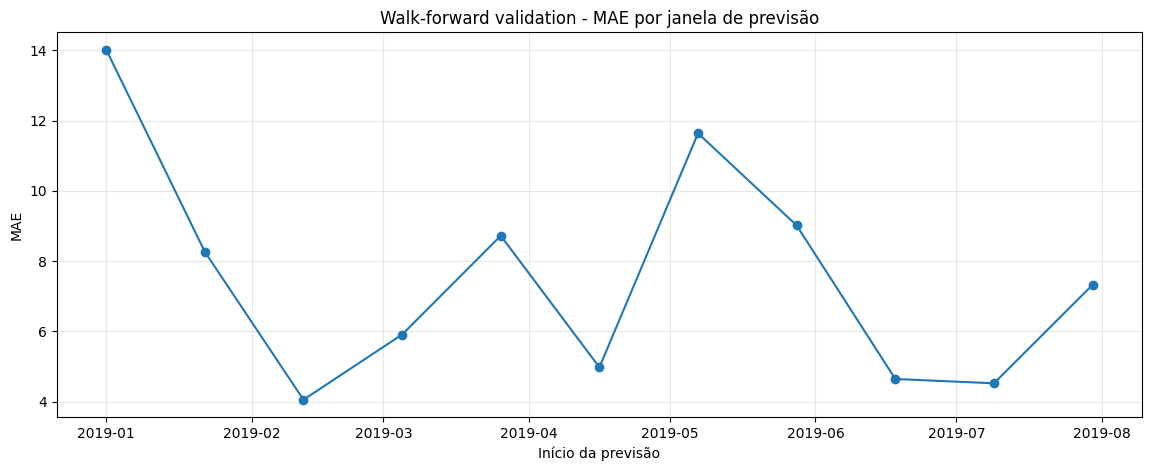

In [51]:
plt.figure(figsize=(14, 5))
plt.plot(df_walk["inicio_previsao"], df_walk["mae"], marker="o")
plt.title("Walk-forward validation - MAE por janela de previsão")
plt.xlabel("Início da previsão")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)
plt.show()

### 9. Experimentos - Resultados



**9.1 Avaliação da melhor configuração**

  - 100% dos dados entre 2016-2019, features (temp, umi, prec, wind), sem interpolação
      - train: (16104, 7) 2016-03-01 00:00:00+00:00 2017-12-31 23:00:00+00:00
      - val  : (8760, 7) 2018-01-01 00:00:00+00:00 2018-12-31 23:00:00+00:00
      - test : (5499, 7) 2019-01-01 00:00:00+00:00 2019-08-18 02:00:00+00:00

**9.1.1 Resultados para o conjunto de Validação 2018-01-01 00:00:00+00:00 2018-12-31 23:00:00+00:00**

    - Validação realizada em janelas de 21 dias ao longo do conjunto de validação

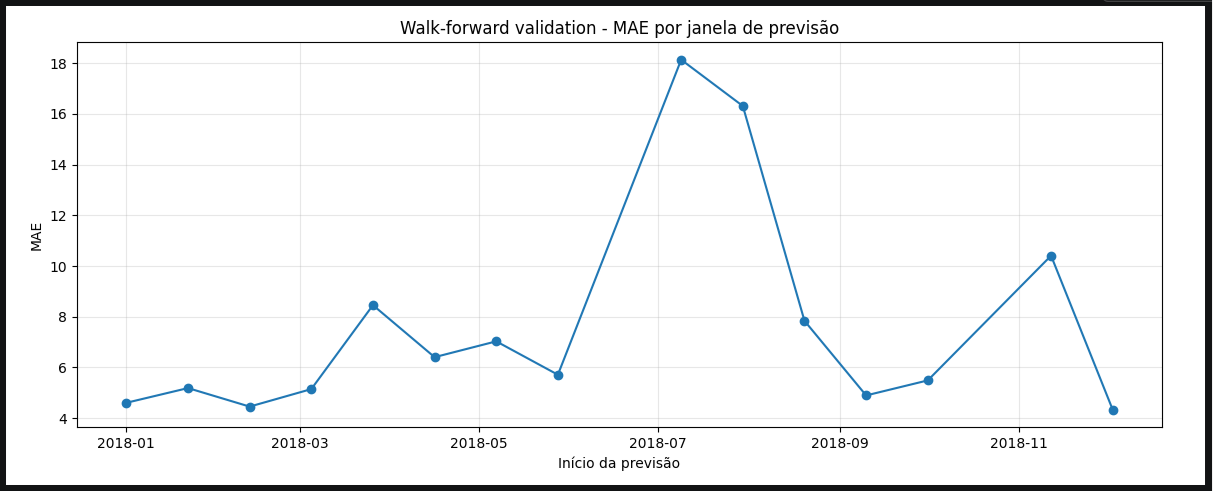

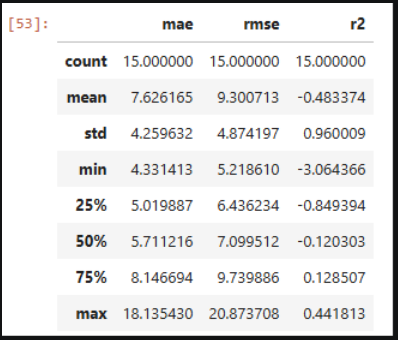


**9.1.2 Resultados para o conjunto de Teste 2019-01-01 00:00:00+00:00 2019-08-18 02:00:00+00:00**

    - Validação realizada em janelas de 21 dias ao longo do conjunto de teste

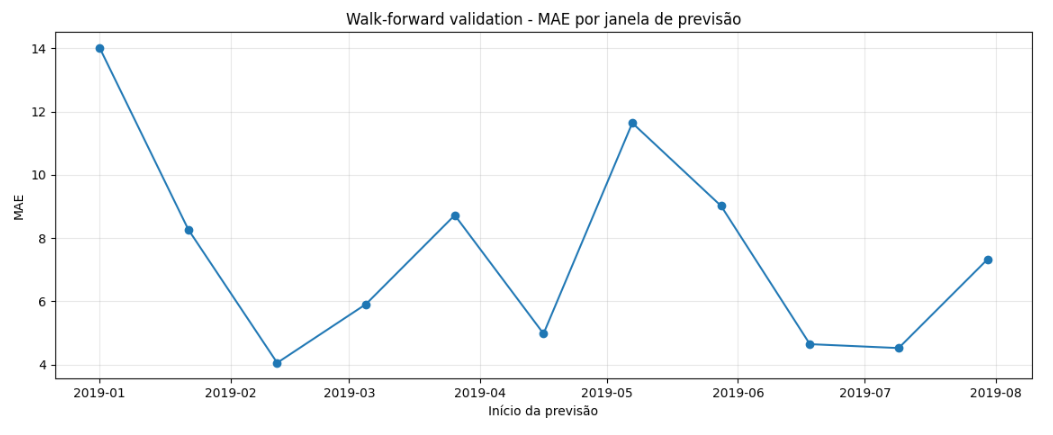

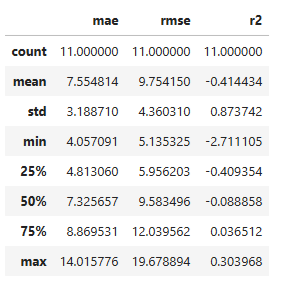

### **10. Memória de calculo dos testes**



**Testes iniciais do conjunto de dados, features, interpolações**

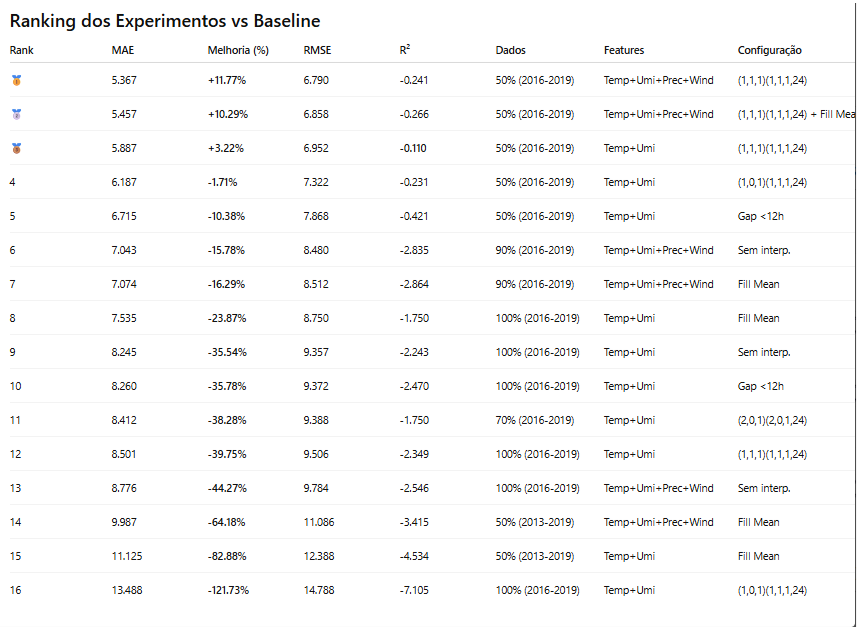

**Testes dos parâmetros do SARIMAX usando melhor conjunto de dados/features/interpolação**

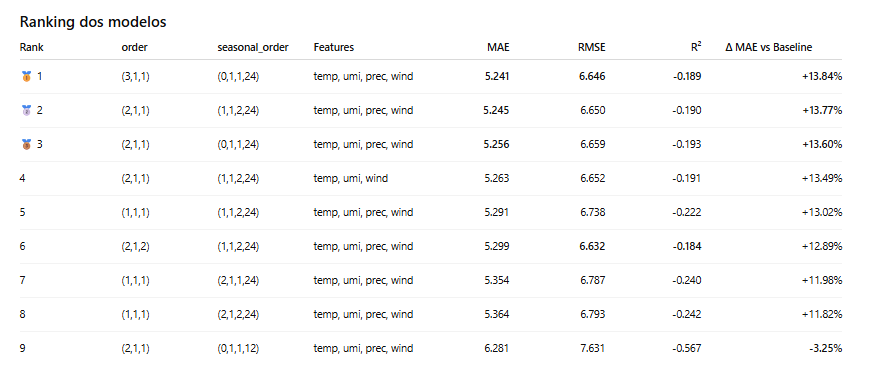

**Teste feito no modelo final adicionando como variáveis exogenas sin_month, cos_month**

  - 100% dos dados de treinamento entre 2016-2019, features (temp, umi, prec, wind, month_sin, month_cos), sem interpolação
      
      - train: (16104, 7) 2016-03-01 00:00:00+00:00 2017-12-31 23:00:00+00:00
      - val  : (8760, 7) 2018-01-01 00:00:00+00:00 2018-12-31 23:00:00+00:00

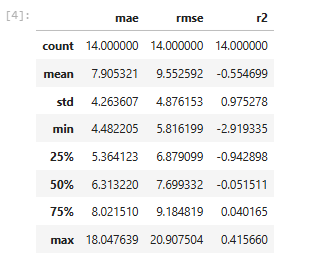

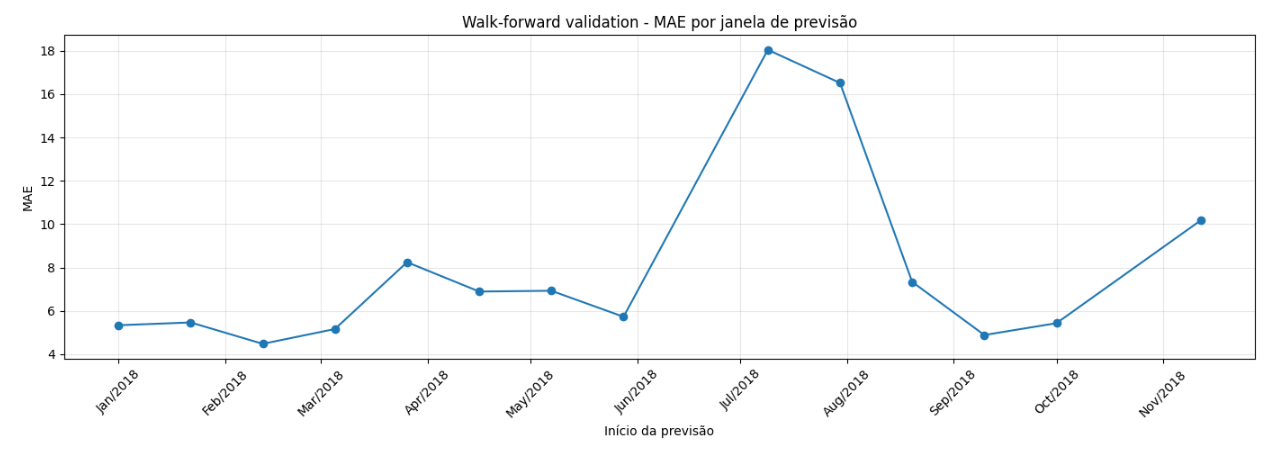